<a href="https://colab.research.google.com/github/yasirsiddiq01/my-python-project/blob/main/6G-channel-estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Check GPU availability
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.19.0


In [2]:
# Install any missing packages (Colab has most pre-installed)
!pip install numpy matplotlib tensorflow scipy

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy import signal
import time

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder for your project
!mkdir -p /content/drive/MyDrive/6G_Channel_Estimation
print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


In [4]:
def generate_realistic_channel_data(num_samples=2000, num_subcarriers=64, snr_db=20):
    """
    Generate realistic wireless channel data with multipath fading
    """
    np.random.seed(42)  # For reproducibility

    # Channel parameters (3GPP-inspired)
    num_paths = 6  # Number of multipath components
    delay_spread = 5  # Maximum delay spread in samples
    doppler_shift = 0.1  # Normalized Doppler frequency

    h_complex = np.zeros((num_samples, num_subcarriers), dtype=complex)

    for i in range(num_samples):
        # Generate multipath channel
        channel_freq = np.zeros(num_subcarriers, dtype=complex)

        for path in range(num_paths):
            # Random complex gain for each path (Rayleigh fading)
            gain = (np.random.randn() + 1j * np.random.randn()) / np.sqrt(2)

            # Random delay
            delay = np.random.randint(0, delay_spread)

            # Frequency response for this path
            phase_rotation = np.exp(-1j * 2 * np.pi * np.arange(num_subcarriers) * delay / num_subcarriers)
            channel_freq += gain * phase_rotation

        # Normalize channel power
        channel_freq = channel_freq / np.sqrt(np.mean(np.abs(channel_freq)**2))
        h_complex[i] = channel_freq

    # Add noise to simulate received pilots
    noise_power = 10 ** (-snr_db / 10)
    noise = (np.random.randn(num_samples, num_subcarriers) +
             1j * np.random.randn(num_samples, num_subcarriers)) * np.sqrt(noise_power / 2)
    received = h_complex + noise

    return received, h_complex

# Generate data
print("Generating channel data...")
received, actual = generate_realistic_channel_data(num_samples=2000, snr_db=15)
print(f"Generated {received.shape[0]} samples with {received.shape[1]} subcarriers")

Generating channel data...
Generated 2000 samples with 64 subcarriers


In [5]:
def prepare_data(complex_data):
    """Convert complex data to real/imag format for CNN"""
    real_part = np.real(complex_data)
    imag_part = np.imag(complex_data)
    return np.stack([real_part, imag_part], axis=-1)

# Split data
split_idx = int(0.8 * len(received))
X_train = prepare_data(received[:split_idx])
y_train = prepare_data(actual[:split_idx])
X_test = prepare_data(received[split_idx:])
y_test = prepare_data(actual[split_idx:])

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (1600, 64, 2)
Test data shape: (400, 64, 2)


In [6]:
def build_advanced_channel_estimator(input_shape=(64, 2)):
    """
    CNN with residual connections and attention mechanism
    Inspired by CTTC's HELENA project
    """
    inputs = layers.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv1D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Residual blocks with attention
    for filters in [64, 128, 64]:
        # Save for residual connection
        shortcut = x

        # Main path
        x = layers.Conv1D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv1D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)

        # Simple attention mechanism
        attention = layers.GlobalAveragePooling1D()(x)
        attention = layers.Dense(filters, activation='sigmoid')(attention)
        attention = layers.Reshape((1, filters))(attention)
        x = layers.Multiply()([x, attention])

        # Residual connection
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.2)(x)

    # Output layer
    outputs = layers.Conv1D(2, 3, padding='same', activation='linear')(x)

    model = models.Model(inputs, outputs)
    return model

# Build model
model = build_advanced_channel_estimator()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 32)    │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 64)    │      6,208 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 64, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 64, 64)    │      2,112 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multiply[0][0],   │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 64, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 175,842 (686.88 KB)

 Trainable params: 174,754 (682.63 KB)

 Non-trainable params: 1,088 (4.25 KB)

In [7]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Callbacks for better training
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/6G_Channel_Estimation/best_model.h5',
        monitor='val_loss',
        save_best_only=True
    )
]

# Train
print("Starting training...")
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

Starting training...
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2898 - mae: 0.3868

40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - loss: 0.2866 - mae: 0.3844 - val_loss: 0.4025 - val_mae: 0.5288 - learning_rate: 0.0010
Epoch 2/30
33/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0556 - mae: 0.1806

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0546 - mae: 0.1789 - val_loss: 0.3494 - val_mae: 0.4934 - learning_rate: 0.0010
Epoch 3/30
34/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0404 - mae: 0.1539

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0399 - mae: 0.1528 - val_loss: 0.2963 - val_mae: 0.4546 - learning_rate: 0.0010
Epoch 4/30
34/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0333 - mae: 0.1409

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0331 - mae: 0.1405 - val_loss: 0.2436 - val_mae: 0.4125 - learning_rate: 0.0010
Epoch 5/30
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0276 - mae: 0.1281

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0166 - mae: 0.1005 - val_loss: 0.0053 - val_mae: 0.0576 - learning_rate: 0.0010
Epoch 18/30
31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0160 - mae: 0.0985

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0162 - mae: 0.0990 - val_loss: 0.0052 - val_mae: 0.0563 - learning_rate: 0.0010
Epoch 19/30
31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0147 - mae: 0.0946

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0147 - mae: 0.0946 - val_loss: 0.0046 - val_mae: 0.0532 - learning_rate: 0.0010
Epoch 20/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0143 - mae: 0.0936 - val_loss: 0.0049 - val_mae: 0.0547 - learning_rate: 0.0010
Epoch 21/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - mae: 0.0933 - val_loss: 0.0053 - val_mae: 0.0573 - learning_rate: 0.0010
Epoch 22/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0143 - mae: 0.0933 - val_loss: 0.0055 - val_mae: 0.0588 - learning_rate: 0.0010
Epoch 23/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0149 - mae: 0.0956 - val_loss: 0.0054 - val_mae: 0.0579 - learning_rate: 0.0010
Epoch 24/30
36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0139 - mae: 0.0923
Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0140 - mae: 0.0924 - val_loss: 0.0055 - val_mae: 0.0587 - learning_rate: 0.0010
Epoch 25/30
34/4

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0125 - mae: 0.0869 - val_loss: 0.0041 - val_mae: 0.0502 - learning_rate: 5.0000e-04
Epoch 26/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0129 - mae: 0.0884 - val_loss: 0.0042 - val_mae: 0.0512 - learning_rate: 5.0000e-04
Epoch 27/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0128 - mae: 0.0886 - val_loss: 0.0041 - val_mae: 0.0504 - learning_rate: 5.0000e-04
Epoch 28/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0131 - mae: 0.0894 - val_loss: 0.0045 - val_mae: 0.0522 - learning_rate: 5.0000e-04
Epoch 29/30
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - mae: 0.0894

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0130 - mae: 0.0893 - val_loss: 0.0038 - val_mae: 0.0483 - learning_rate: 5.0000e-04
Epoch 30/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0125 - mae: 0.0873 - val_loss: 0.0043 - val_mae: 0.0517 - learning_rate: 5.0000e-04
Training completed in 41.46 seconds


In [8]:
def least_squares_estimate(received):
    """Least squares channel estimation"""
    return received  # Simplified - in reality uses pilot symbols

def linear_interpolation_estimate(received):
    """Linear interpolation between pilots"""
    # Simplified - assumes pilots every 4th subcarrier
    estimated = received.copy()
    for i in range(estimated.shape[0]):
        for j in range(0, estimated.shape[1], 4):
            if j+4 < estimated.shape[1]:
                # Linear interpolation between pilots
                start, end = estimated[i, j], estimated[i, j+4]
                for k in range(1, 4):
                    alpha = k / 4
                    estimated[i, j+k] = (1-alpha) * start + alpha * end
    return estimated

# Get predictions
print("Evaluating different methods...")
cnn_estimate = model.predict(X_test)

# Convert to complex for comparison
def to_complex(data):
    return data[..., 0] + 1j * data[..., 1]

cnn_complex = to_complex(cnn_estimate)
ls_complex = least_squares_estimate(received[split_idx:])
actual_complex = actual[split_idx:]

# Calculate MSE
ls_mse = np.mean(np.abs(ls_complex - actual_complex)**2)
cnn_mse = np.mean(np.abs(cnn_complex - actual_complex)**2)

print(f"\n📊 Results:")
print(f"Least Squares MSE: {ls_mse:.6f}")
print(f"CNN MSE: {cnn_mse:.6f}")
print(f"Improvement: {(1 - cnn_mse/ls_mse)*100:.2f}%")

Evaluating different methods...
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step

📊 Results:
Least Squares MSE: 0.031676
CNN MSE: 0.007388
Improvement: 76.68%


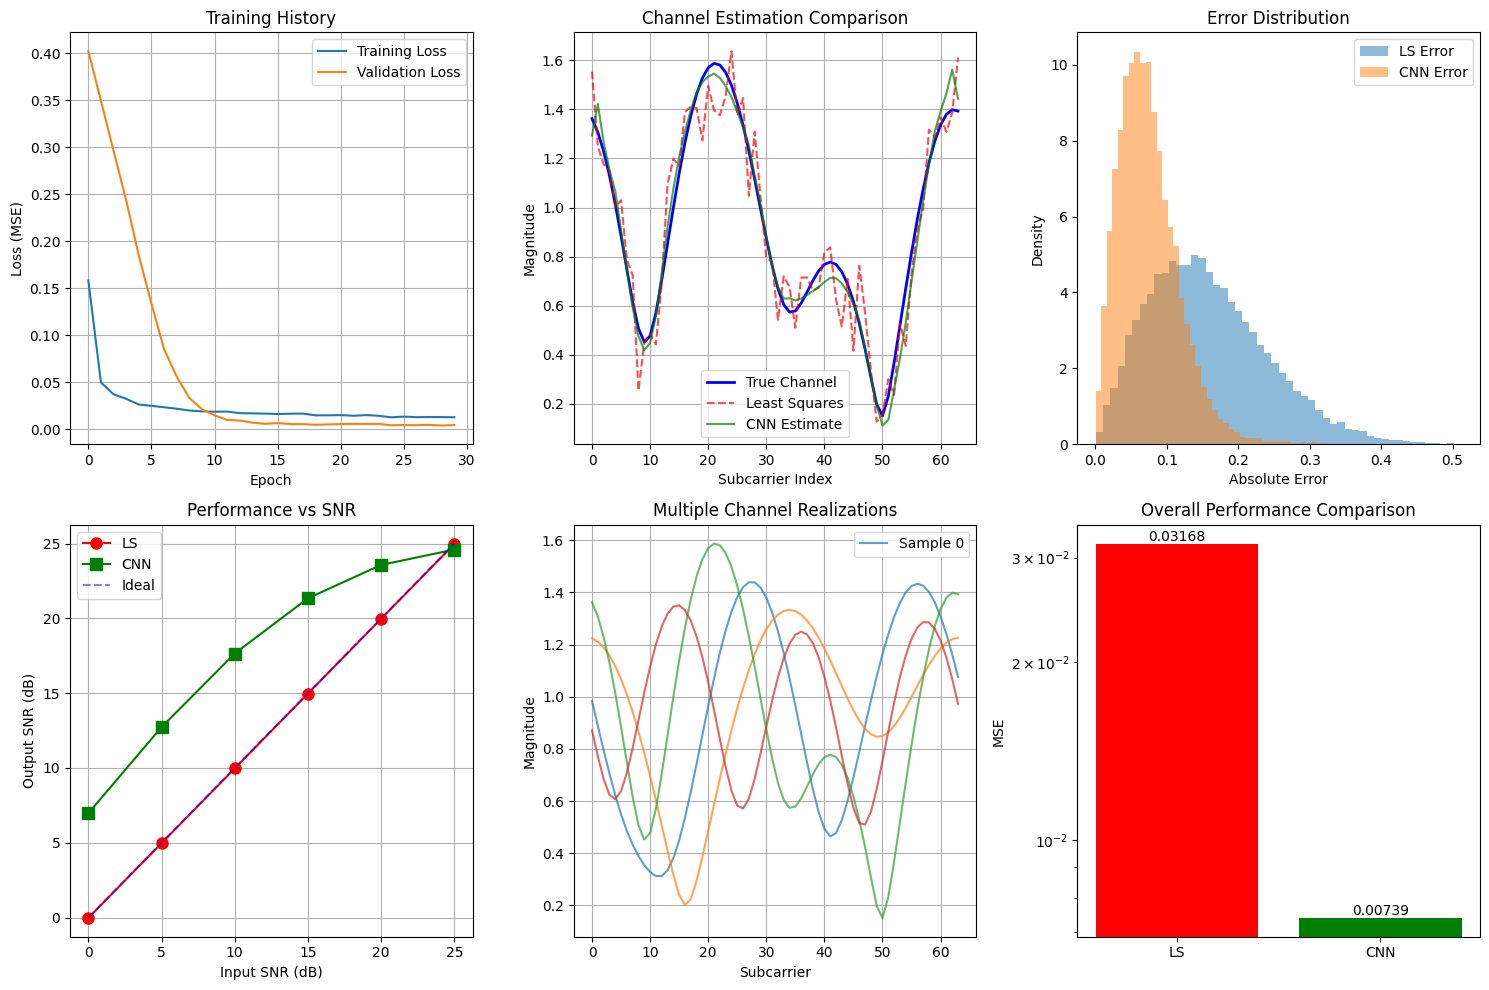

✅ Results saved to Google Drive


In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Training history
axes[0,0].plot(history.history['loss'], label='Training Loss')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss (MSE)')
axes[0,0].set_title('Training History')
axes[0,0].legend()
axes[0,0].grid(True)

# Sample comparison
sample_idx = 10
axes[0,1].plot(np.abs(actual_complex[sample_idx]), 'b-', label='True Channel', linewidth=2)
axes[0,1].plot(np.abs(ls_complex[sample_idx]), 'r--', label='Least Squares', alpha=0.7)
axes[0,1].plot(np.abs(cnn_complex[sample_idx]), 'g-', label='CNN Estimate', alpha=0.7)
axes[0,1].set_xlabel('Subcarrier Index')
axes[0,1].set_ylabel('Magnitude')
axes[0,1].set_title('Channel Estimation Comparison')
axes[0,1].legend()
axes[0,1].grid(True)

# Error distribution
ls_error = np.abs(ls_complex - actual_complex).flatten()
cnn_error = np.abs(cnn_complex - actual_complex).flatten()
axes[0,2].hist(ls_error, bins=50, alpha=0.5, label='LS Error', density=True)
axes[0,2].hist(cnn_error, bins=50, alpha=0.5, label='CNN Error', density=True)
axes[0,2].set_xlabel('Absolute Error')
axes[0,2].set_ylabel('Density')
axes[0,2].set_title('Error Distribution')
axes[0,2].legend()

# SNR vs Performance (simulate different SNRs)
snr_values = [0, 5, 10, 15, 20, 25]
ls_perf = []
cnn_perf = []

for snr in snr_values:
    rec, act = generate_realistic_channel_data(num_samples=200, snr_db=snr)
    X = prepare_data(rec)
    cnn_est = model.predict(X, verbose=0)
    cnn_est_c = to_complex(cnn_est)

    ls_mse_snr = np.mean(np.abs(rec - act)**2)
    cnn_mse_snr = np.mean(np.abs(cnn_est_c - act)**2)

    ls_perf.append(10*np.log10(1/ls_mse_snr))
    cnn_perf.append(10*np.log10(1/cnn_mse_snr))

axes[1,0].plot(snr_values, ls_perf, 'ro-', label='LS', markersize=8)
axes[1,0].plot(snr_values, cnn_perf, 'gs-', label='CNN', markersize=8)
axes[1,0].plot(snr_values, snr_values, 'b--', label='Ideal', alpha=0.5)
axes[1,0].set_xlabel('Input SNR (dB)')
axes[1,0].set_ylabel('Output SNR (dB)')
axes[1,0].set_title('Performance vs SNR')
axes[1,0].legend()
axes[1,0].grid(True)

# Multiple samples comparison
sample_indices = [0, 5, 10, 15]
for i, idx in enumerate(sample_indices):
    axes[1,1].plot(np.abs(actual_complex[idx]), alpha=0.7, label=f'Sample {idx}' if i==0 else "")
axes[1,1].set_xlabel('Subcarrier')
axes[1,1].set_ylabel('Magnitude')
axes[1,1].set_title('Multiple Channel Realizations')
axes[1,1].legend()
axes[1,1].grid(True)

# Bar chart comparison
methods = ['LS', 'CNN']
mse_values = [ls_mse, cnn_mse]
bars = axes[1,2].bar(methods, mse_values, color=['red', 'green'])
axes[1,2].set_ylabel('MSE')
axes[1,2].set_title('Overall Performance Comparison')
axes[1,2].set_yscale('log')
for bar, val in zip(bars, mse_values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                  f'{val:.5f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6G_Channel_Estimation/results.png', dpi=150)
plt.show()
print("✅ Results saved to Google Drive")

In [10]:
# Save the model in different formats
model.save('/content/drive/MyDrive/6G_Channel_Estimation/final_model.h5')

# Convert to TensorFlow Lite for potential edge deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('/content/drive/MyDrive/6G_Channel_Estimation/model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model saved successfully")
print("\n📁 Files saved in your Google Drive:")
print("   - 6G_Channel_Estimation/best_model.h5")
print("   - 6G_Channel_Estimation/final_model.h5")
print("   - 6G_Channel_Estimation/model.tflite")
print("   - 6G_Channel_Estimation/results.png")

Saved artifact at '/tmp/tmp4xf41yu3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 64, 2), dtype=tf.float32, name=None)
Captures:
  137106268730192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268733264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268732688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268730960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268730576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268731920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268732112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268732304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106138907856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106138908048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137106268732880:

In [11]:
# Quick test with smaller dataset
received_small, actual_small = generate_realistic_channel_data(num_samples=500)

X_small = prepare_data(received_small[:400])
y_small = prepare_data(actual_small[:400])
X_test_small = prepare_data(received_small[400:])
y_test_small = prepare_data(actual_small[400:])

# Build smaller model for quick testing
quick_model = models.Sequential([
    layers.Input(shape=(64, 2)),
    layers.Conv1D(16, 3, activation='relu', padding='same'),
    layers.Conv1D(32, 3, activation='relu', padding='same'),
    layers.Conv1D(2, 3, activation='linear', padding='same')
])

quick_model.compile(optimizer='adam', loss='mse')
quick_model.fit(X_small, y_small, epochs=5, validation_split=0.2, verbose=1)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 0.3961 - val_loss: 0.2428
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2033 - val_loss: 0.1178
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0945 - val_loss: 0.0539
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0443 - val_loss: 0.0309
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0268 - val_loss: 0.0180
